## `IMPORT LIBRARY & LOAD DATASET`

In [1]:
import numpy as np
import pandas as pd
import os
import nltk
import string
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences



[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
2026-04-04 07:59:19.858936: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775289560.086587      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775289560.151659      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775289560.660743      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775289560

In [2]:

BATCH_SIZE = 32
EPOCHS = 5

file_path = None

for dirname ,_ , filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.json'):
            file_path = os.path.join(dirname, filename)

print("file path:", file_path)
df = pd.read_json(file_path, lines = True)    

file path: /kaggle/input/datasets/rmisra/news-category-dataset/News_Category_Dataset_v3.json


## `EDA`

1. Dataset overview
2. Category distribution
3. Text length distribution
5. Vocabulary analysis (size + richness by category + most frequent word + rare word)
6.  TF-IDF terms
7.   N-grams
8.   Category similarity

# 1. Dataset overview

In [3]:
df["text"] = df["headline"] + " " + df["short_description"]

print("Number of samples: ", len(df["text"]))
print("Number of categories: ", df["category"].nunique())

np.random.seed(42)
categories = df["category"].unique()
sample_categories = np.random.choice(categories,10,replace = False)
samples = []
for cat in sample_categories:
    sample = df[df["category"] == cat].sample(1)
    samples.append(sample)
    
sample_df = pd.concat(samples)
sample_df = sample_df.reset_index(drop = True)
print(sample_df[["category", "text"]])

Number of samples:  209527
Number of categories:  42
         category                                               text
0        RELIGION  Bowe Bergdahl's Pastor Explains His Faith Back...
1         SCIENCE  Eclipses in the October Skies When the Moon is...
2        POLITICS  The United Debacle Shows Airlines Have Given U...
3   LATINO VOICES  Gina Rodriguez Goes Full 'Fifty Shades Of Jane...
4  CULTURE & ARTS  Pieter Hugo on the ImageBlog Pieter Hugo From ...
5           FIFTY  Why Change Sucks Even When You're Middle Age C...
6    QUEER VOICES  Meet The Transgender Teen Heading To SCOTUS To...
7         COLLEGE  Class Clown to Class President There was alway...
8         PARENTS  Why I'm Proud of My Son's Low GPA Success to u...
9          SPORTS  The NFL, MLB and Viagra: So Much for Family-Fr...


# 2. Category distribution

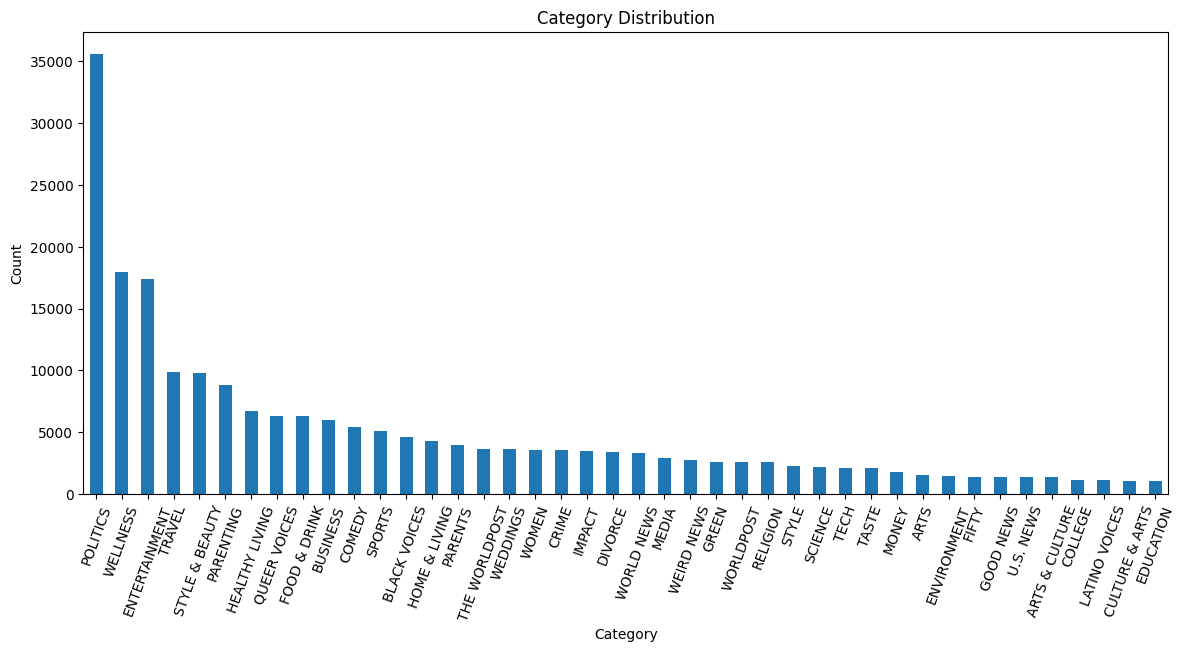

In [4]:
category_counts = df["category"].value_counts()

plt.figure(figsize = (14,6))
category_counts.plot(kind="bar")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=70)
plt.show()

# 3. Text length analysis

In [5]:
def raw_tokenize(text):
    return nltk.word_tokenize(text.lower())
    
def clean_tokenize(text):
    tokens = nltk.word_tokenize(text.lower())
    return [
        w for w in tokens
        if w not in stop_words
        and w not in string.punctuation
        and w.isalpha()
    ]

df["tokens"] = df["text"].apply(raw_tokenize)

all_words = [word for tokens in df["tokens"] for word in tokens]
vocab = set(all_words)

print("Vocabulary size:", len(vocab))

Vocabulary size: 120874


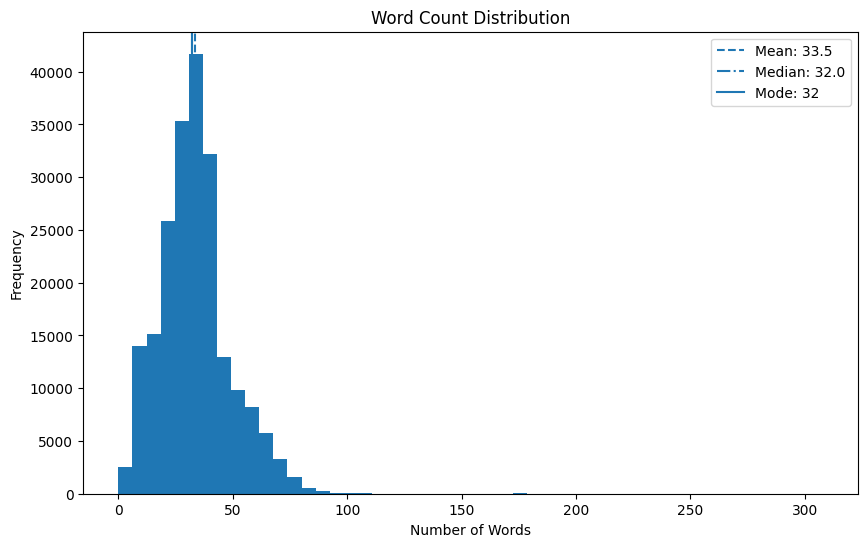

In [6]:
df["word_count"] = df["tokens"].apply(len)
mean = df["word_count"].mean()
median = df["word_count"].median()
mode = df["word_count"].mode()[0]

plt.figure(figsize=(10,6))
plt.hist(df["word_count"], bins=50)

# add lines
plt.axvline(mean, linestyle='--', label=f"Mean: {mean:.1f}")
plt.axvline(median, linestyle='-.', label=f"Median: {median}")
plt.axvline(mode, linestyle='-', label=f"Mode: {mode}")

plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend()

plt.show()

# 4. STOPWORDS ANALYSIS

In [7]:
stop_words = set(stopwords.words('english'))

counter = Counter(all_words)
total_words = sum(counter.values())
stopword_counts = {word: count for word, count in counter.items() if word in stop_words}
total_stopwords = sum(stopword_counts.values())

print("Total words:", total_words)
print("Total stopwords:", total_stopwords)
print("Stopword ratio:", total_stopwords / total_words)

Total words: 7025173
Total stopwords: 2464543
Stopword ratio: 0.35081598702266836


# STOPWORDS FREQUENCY 

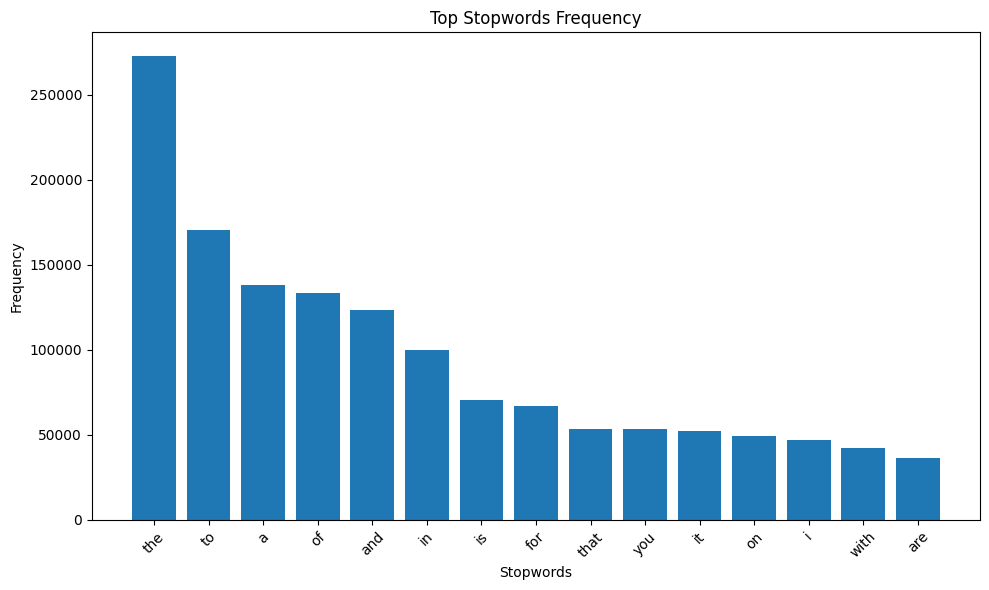

In [8]:
top_stopwords = sorted(stopword_counts.items(), key=lambda x: x[1], reverse=True)[:15]

# Unpack
words, counts = zip(*top_stopwords)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(words, counts)

plt.xticks(rotation=45)
plt.title("Top Stopwords Frequency")
plt.xlabel("Stopwords")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# 5. VOCABULARY ANALYSIS

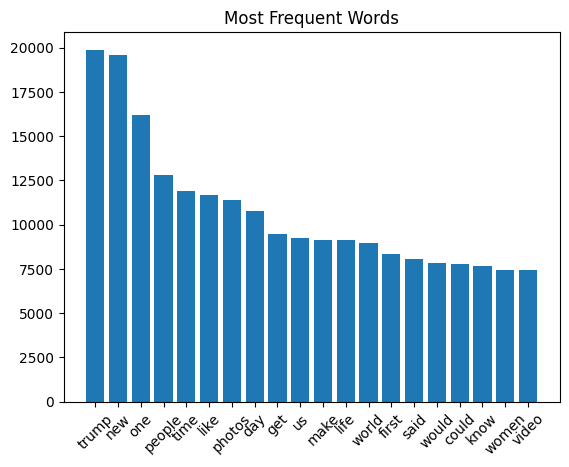

In [9]:
df["tokens"] = df["text"].apply(clean_tokenize)
df["clean_text"] = df["tokens"].apply(lambda tokens: " ".join(tokens))

all_words = [word for tokens in df["tokens"] for word in tokens]
vocab = set(all_words)

counter = Counter(all_words)

most_common = counter.most_common(20)

words, counts = zip(*most_common)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Most Frequent Words")
plt.show()

In [10]:
def vocab_stats(group):
    # flatten all tokens in this category
    all_words = [word for tokens in group["tokens"] for word in tokens]
    
    total_words = len(all_words)
    unique_words = len(set(all_words))
    articles = len(group)
    
    ttr = unique_words / total_words if total_words > 0 else 0
    
    return pd.Series({
        "Total Words": total_words,
        "Unique Words": unique_words,
        "TTR (%)": ttr * 100,
        "Articles": articles
    })

vocab_table = df.groupby("category").apply(vocab_stats)
vocab_table["TTR (%)"] = vocab_table["TTR (%)"].round(2)

print(vocab_table)

                Total Words  Unique Words  TTR (%)  Articles
category                                                    
ARTS                26057.0        8674.0    33.29    1509.0
ARTS & CULTURE      18539.0        6612.0    35.67    1339.0
BLACK VOICES        74328.0       12368.0    16.64    4583.0
BUSINESS           105662.0       15111.0    14.30    5992.0
COLLEGE             20157.0        5858.0    29.06    1144.0
COMEDY              72070.0       12619.0    17.51    5400.0
CRIME               53638.0       10146.0    18.92    3562.0
CULTURE & ARTS      21982.0        7769.0    35.34    1074.0
DIVORCE             62093.0        9443.0    15.21    3426.0
EDUCATION           20324.0        5668.0    27.89    1014.0
ENTERTAINMENT      239163.0       23400.0     9.78   17362.0
ENVIRONMENT         29331.0        7991.0    27.24    1444.0
FIFTY               29106.0        7222.0    24.81    1401.0
FOOD & DRINK        94055.0       12939.0    13.76    6340.0
GOOD NEWS           1757

/tmp/ipykernel_55/2990300124.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vocab_table = df.groupby("category").apply(vocab_stats)


# TF-IDF top terms

In [11]:
vectorizer = TfidfVectorizer(max_features=5000)

X_tfidf = vectorizer.fit_transform(df["clean_text"])

feature_names = np.array(vectorizer.get_feature_names_out())

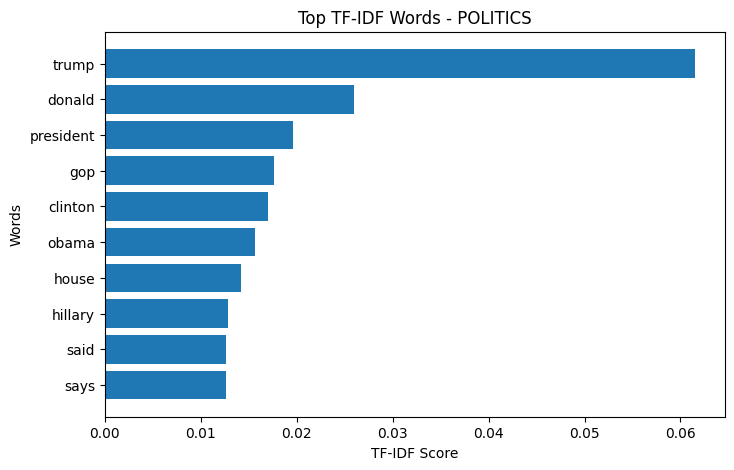

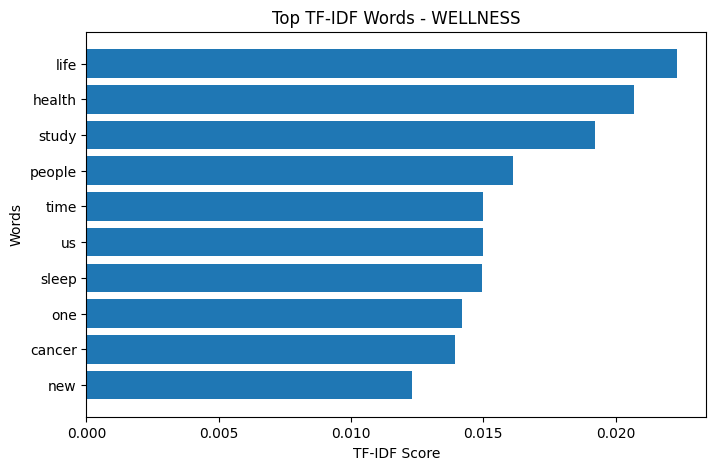

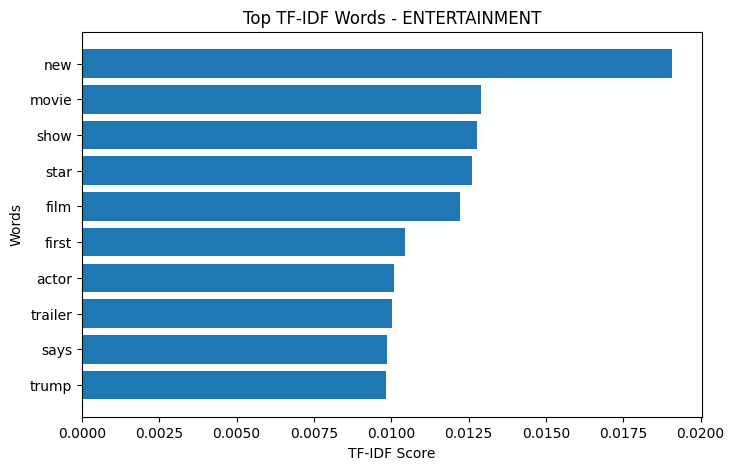

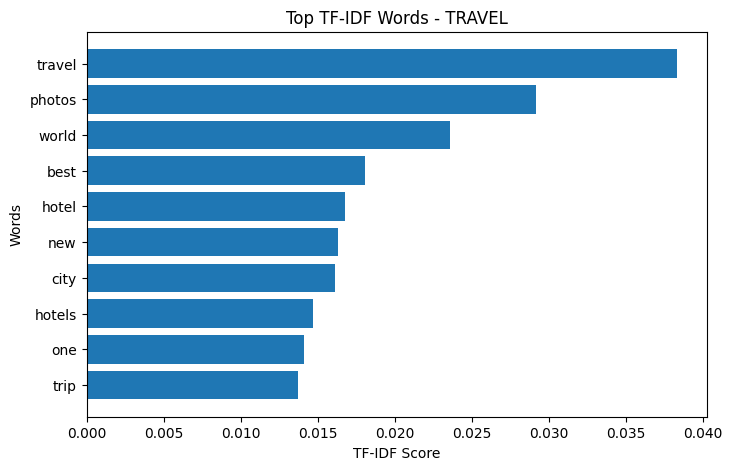

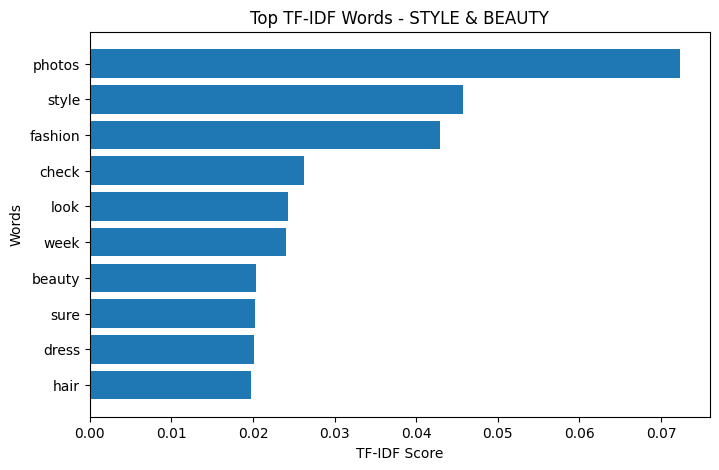

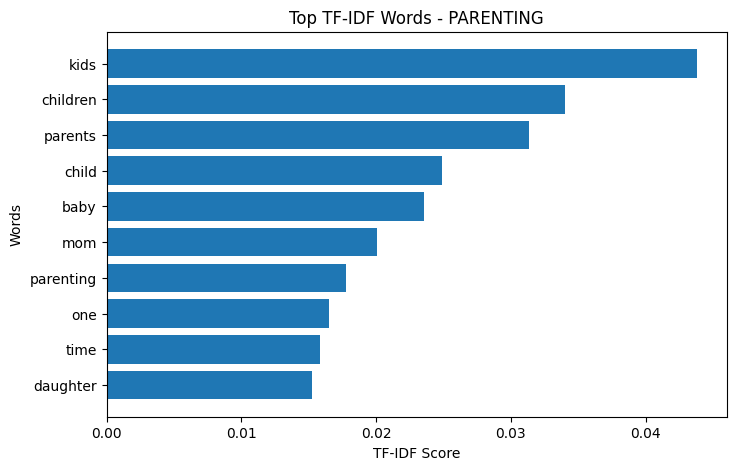

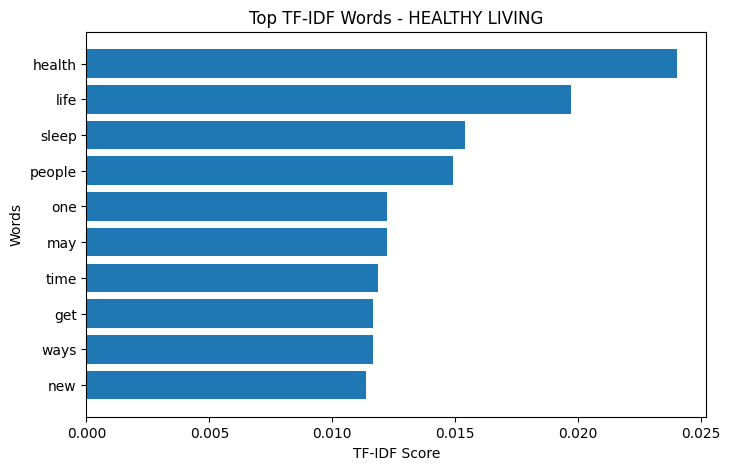

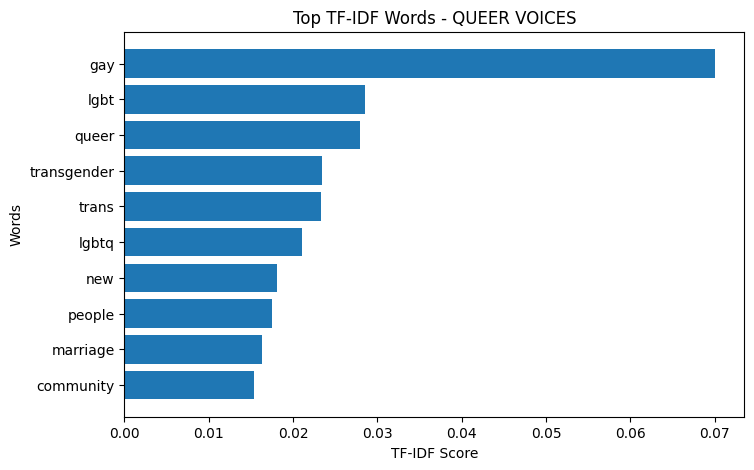

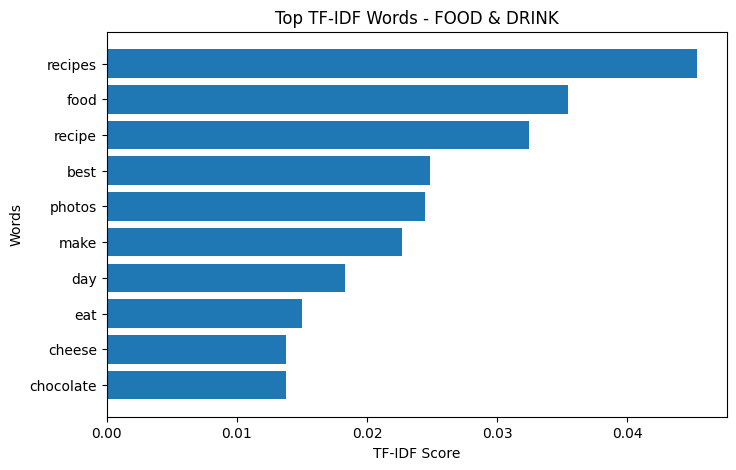

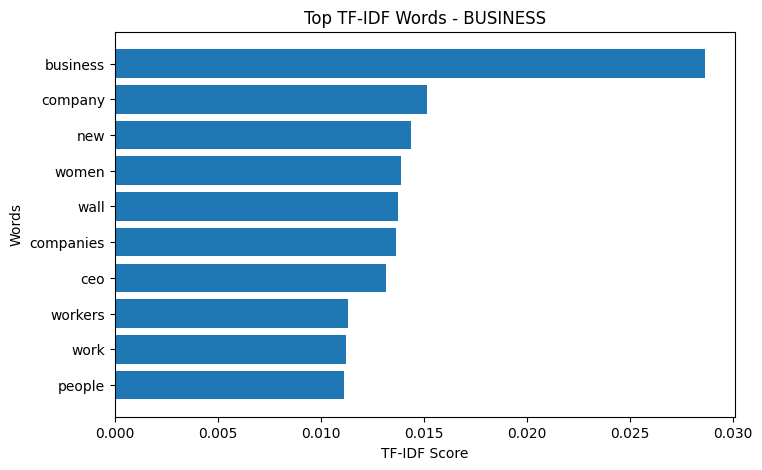

In [12]:
def plot_tfidf_terms_per_class(X, y, feature_names, top_n=10):
    top_categories = df["category"].value_counts().index[:10]
    for category in top_categories:
        idx = np.where(y == category)
        mean_tfidf = X[idx].mean(axis=0).A1
        
        top_indices = np.argsort(mean_tfidf)[-top_n:][::-1]
        
        top_words = [feature_names[i] for i in top_indices]
        top_scores = [mean_tfidf[i] for i in top_indices]
        
        plt.figure(figsize=(8, 5))
        plt.barh(top_words, top_scores)
        plt.gca().invert_yaxis()  # highest on top
        
        plt.title(f"Top TF-IDF Words - {category}")
        plt.xlabel("TF-IDF Score")
        plt.ylabel("Words")
plot_tfidf_terms_per_class(X_tfidf, df["category"].values, feature_names)

# Meaningful phrase pattern

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(1, 3))  

X_ngram = vectorizer.fit_transform(df["clean_text"])
feature_names = vectorizer.get_feature_names_out()

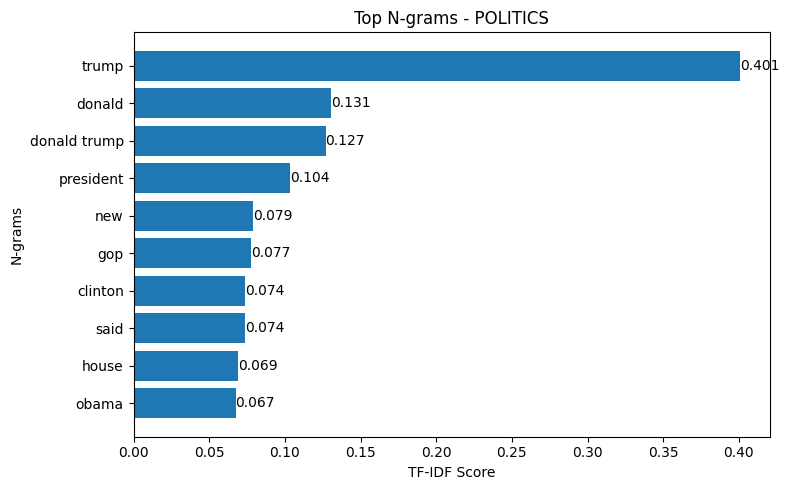

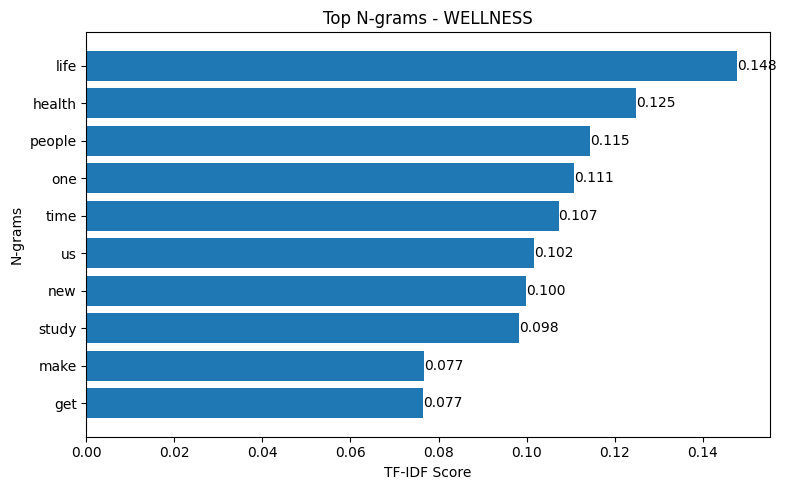

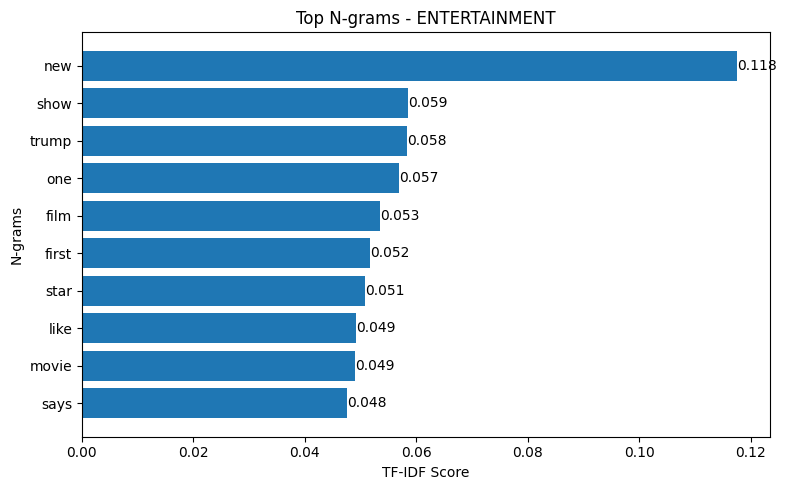

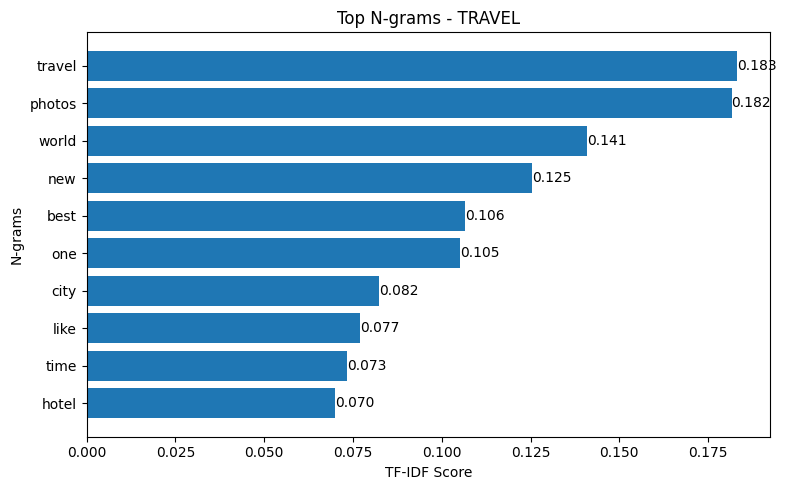

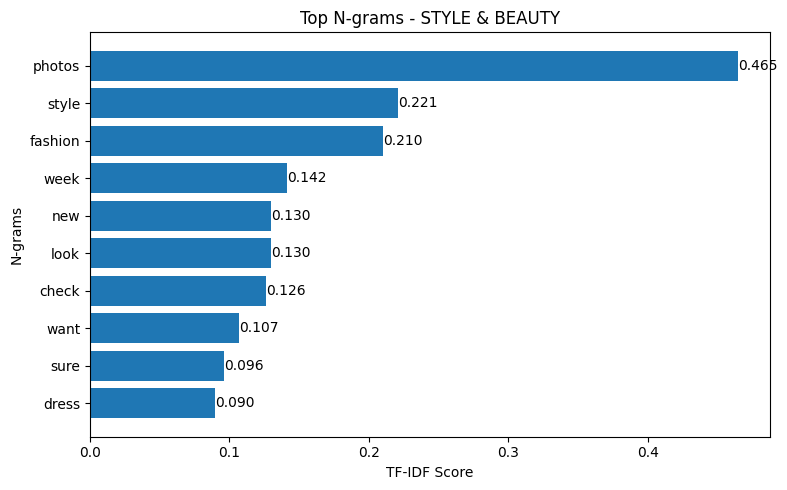

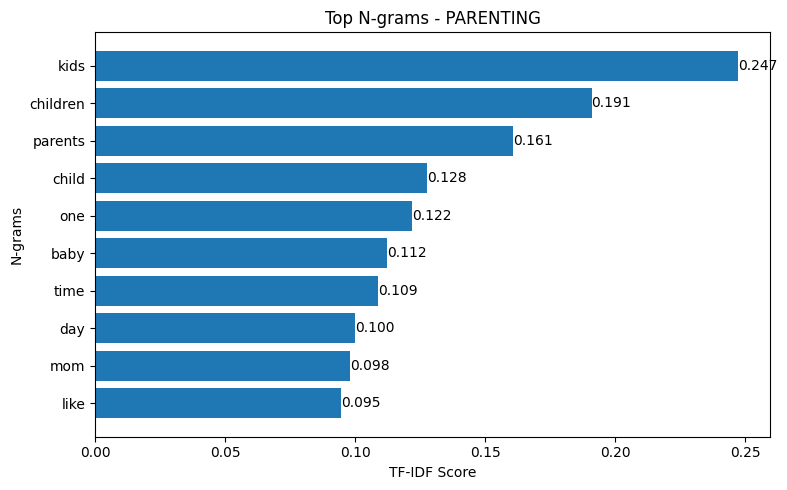

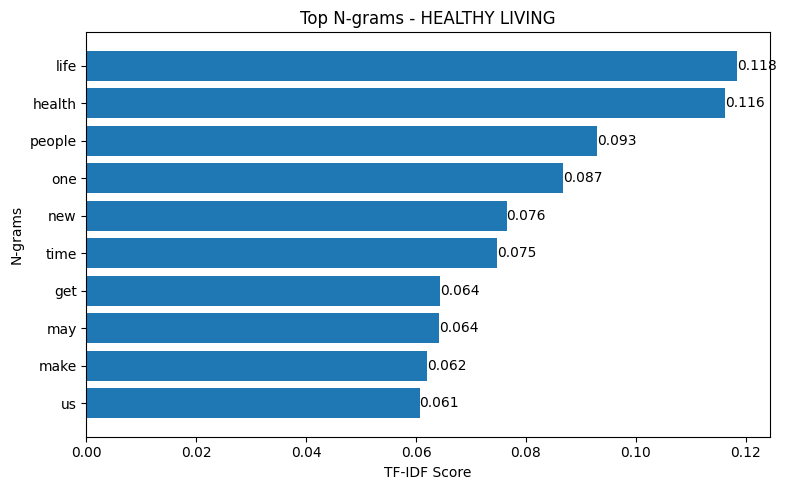

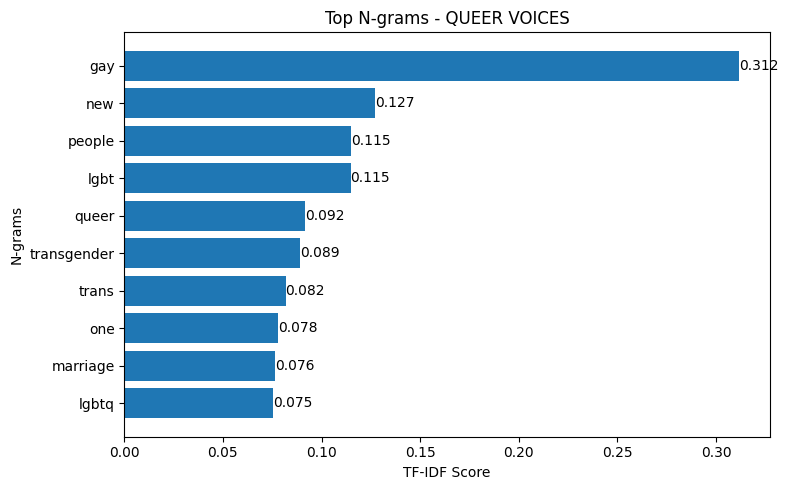

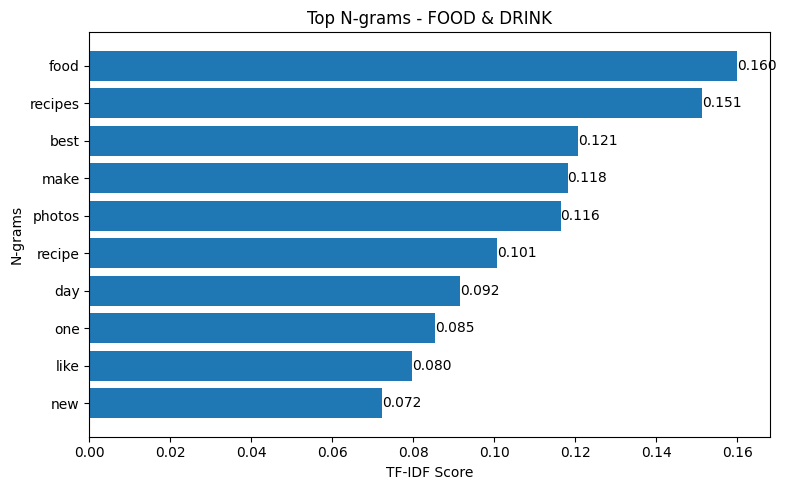

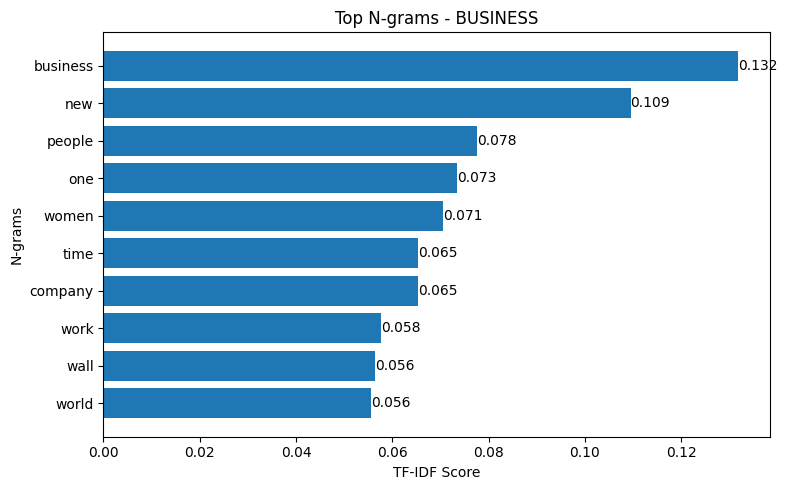

In [14]:
def plot_ngrams_per_category(X, y, feature_names, top_n=10):
    categories = np.unique(y)
    top_categories = df["category"].value_counts().index[:10]
    for category in top_categories:
        idx = np.where(y == category)[0]
        
        # extract sub-matrix
        X_cat = X[idx]
        
        # mean TF-IDF
        mean_scores = np.asarray(X_cat.mean(axis=0)).ravel()
        
        # keep non-zero only
        nonzero = mean_scores > 0
        filtered_scores = mean_scores[nonzero]
        filtered_features = feature_names[nonzero]
        
        # top N
        top_indices = np.argsort(filtered_scores)[-top_n:][::-1]
        
        top_words = [filtered_features[i] for i in top_indices]
        top_scores = [filtered_scores[i] for i in top_indices]
        
        # PLOT 
        plt.figure(figsize=(8,5))
        plt.barh(top_words, top_scores)
        plt.gca().invert_yaxis()  # highest on top
        
        plt.title(f"Top N-grams - {category}")
        plt.xlabel("TF-IDF Score")
        plt.ylabel("N-grams")
        
        # add values on bars
        for i, v in enumerate(top_scores):
            plt.text(v, i, f"{v:.3f}", va='center')
        
        plt.tight_layout()
        plt.show()

plot_ngrams_per_category(
    X_ngram,
    df["category"].values,
    feature_names
)

# 6. Category similarity

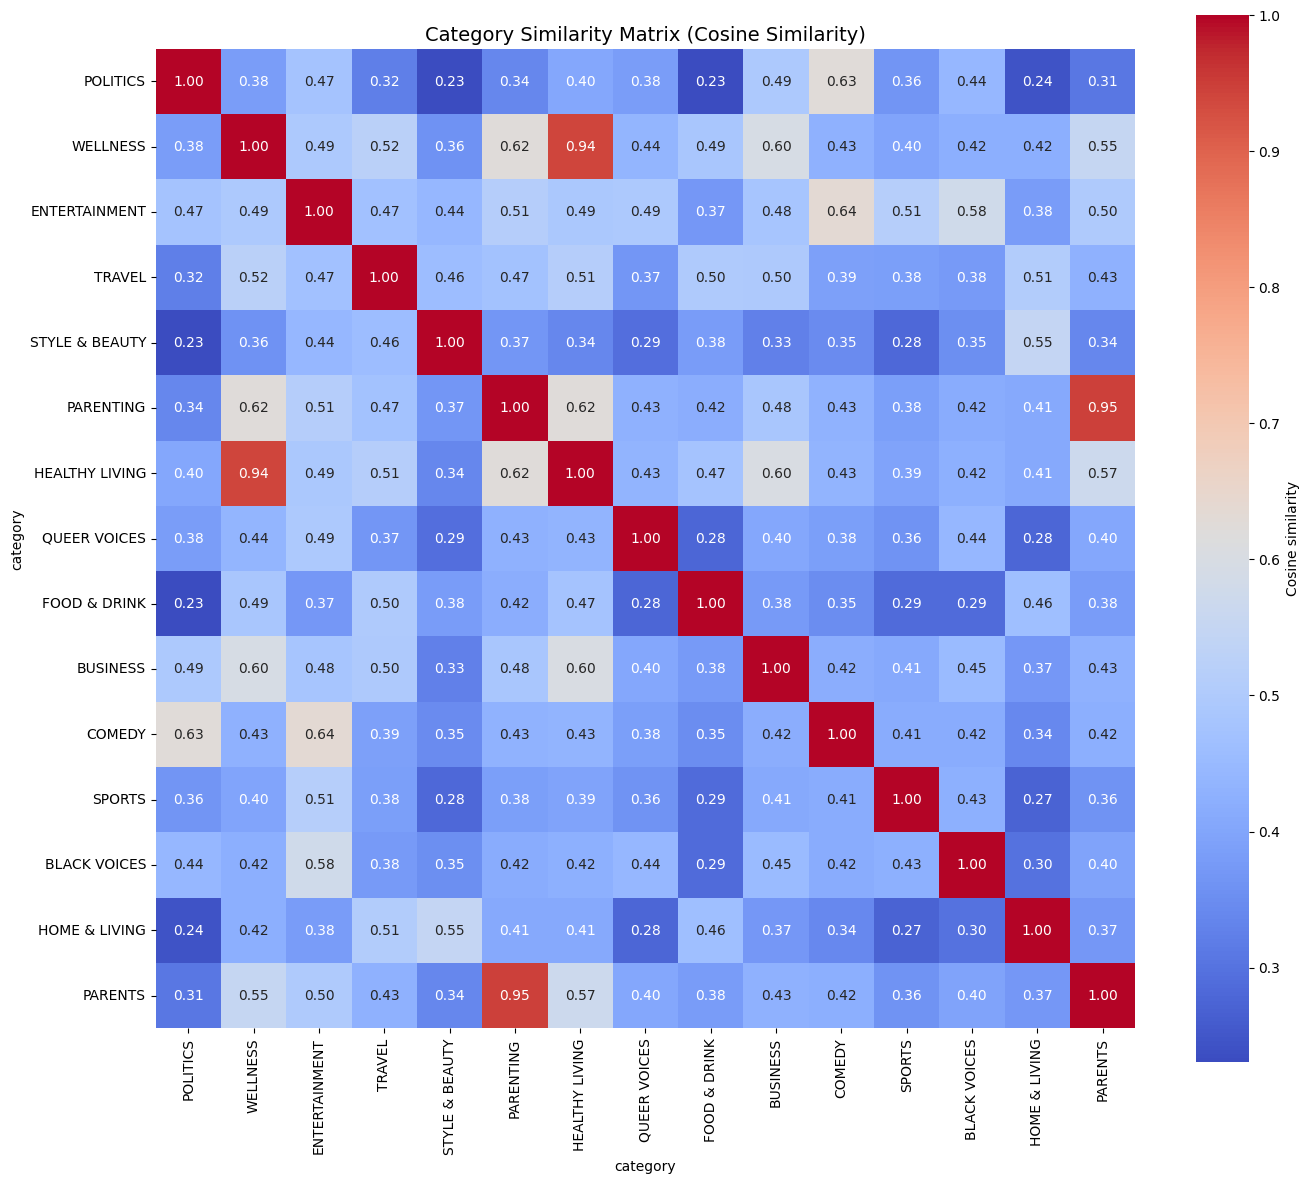

In [15]:
import seaborn as sns

top_categories = df["category"].value_counts().index[:15]
df_top = df[df["category"].isin(top_categories)]

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df_top["clean_text"])

categories = df_top["category"].values

category_vectors = []

for cat in top_categories:
    idx = np.where(categories == cat)[0]
    category_vector = np.asarray(X[idx].mean(axis=0)).flatten()
    category_vectors.append(category_vector)

category_matrix = np.vstack(category_vectors)
sim = cosine_similarity(category_matrix)

sim_df = pd.DataFrame(
    sim,
    index=top_categories,
    columns=top_categories
)

plt.figure(figsize=(14,12))

sns.heatmap(
    sim_df,
    cmap="coolwarm",
    annot=True,        
    fmt=".2f",         
    square=True,
    cbar_kws={"label": "Cosine similarity"}
)

plt.title("Category Similarity Matrix (Cosine Similarity)", fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## `PREPROCESSING`

# CHOOSING SUBSET

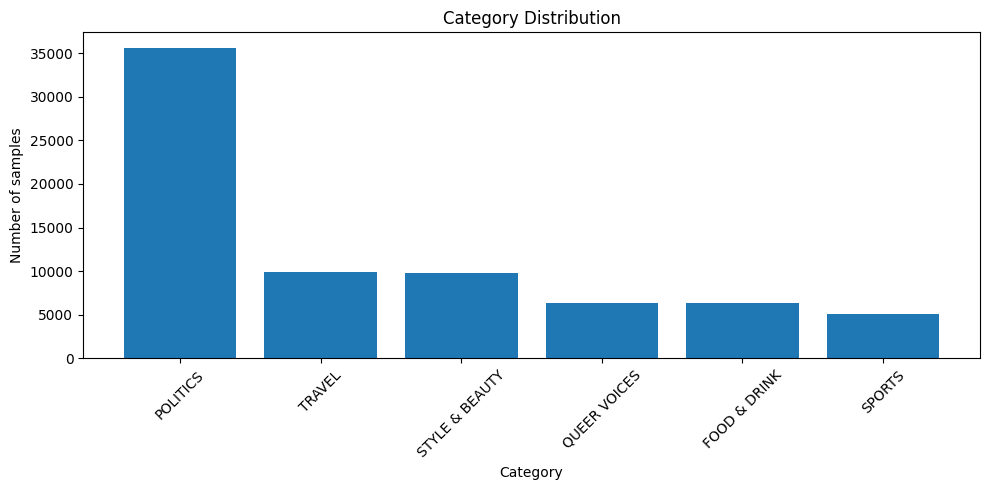

In [16]:
CATEGORIES = [
    "POLITICS",
    "TRAVEL",
    "STYLE & BEAUTY",
    "QUEER VOICES",
    "FOOD & DRINK",
    "SPORTS",
]
df = df[df["category"].isin(CATEGORIES)].copy()
df = df.reset_index(drop=True)   # clean 0-based index

counts = df["category"].value_counts()

plt.figure(figsize=(10,5))
plt.bar(counts.index, counts.values)

plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of samples")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# TOKENIZATION

In [17]:
def clean_text(text):
    text = text.lower()  # lowercase
    
    # remove punctuation + numbers
    text = re.sub(r"[^\w\s]", " ", text)   # remove punctuation
    text = re.sub(r"\d+", " ", text)       # remove numbers
    
    tokens = word_tokenize(text)
    
    # remove extra spaces + short tokens
    tokens = [t for t in tokens if len(t) > 1]
    
    return tokens

df["tokens"] = df["text"].apply(clean_text)

# LABEL ENCODING

In [18]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["category"])
num_classes = len(le.classes_)
print(dict(zip(le.classes_, range(num_classes))))

{'FOOD & DRINK': 0, 'POLITICS': 1, 'QUEER VOICES': 2, 'SPORTS': 3, 'STYLE & BEAUTY': 4, 'TRAVEL': 5}


# VOCABULARY BUILD

In [19]:
all_tokens = [word for tokens in df["tokens"] for word in tokens]
counter = Counter(all_tokens)

# remove rare words 
min_freq = 2

filtered_words = [(w, c) for w, c in counter.items() if c >= min_freq]
filtered_words = sorted(filtered_words, key=lambda x: x[1], reverse=True)

PAD = 0
OOV = 1

vocab = {"<PAD>": PAD, "<OOV>": OOV}

for i, (word, _) in enumerate(filtered_words):
    vocab[word] = i + 2

vocab_size = len(vocab)
input_size = vocab_size

print("Vocab size:", vocab_size)

Vocab size: 33464


# ENCODING

In [20]:
def encode(tokens):
    return [
        vocab.get(word, OOV)
        for word in tokens
    ]

df["seq"] = df["tokens"].apply(encode)

# PADDING

In [21]:
max_len = 60  # tune this

x = pad_sequences(
    df["seq"],
    maxlen=max_len,
    padding="post",
    truncating="post"
)
y = df["label"].values

# TRAIN/VAL/TEST SPLIT

In [22]:
x_train, x_temp, y_train, y_temp = train_test_split(
    x,y,
    test_size = 0.3,
    random_state = 42,
    stratify = y
)
x_test, x_val, y_test, y_val = train_test_split(
    x_temp,y_temp,
    test_size = 0.5,
    random_state = 42,
    stratify = y_temp
)

In [23]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [24]:
train_loader = DataLoader(TextDataset(x_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(TextDataset(x_val, y_val), batch_size=32)
test_loader  = DataLoader(TextDataset(x_test, y_test), batch_size=32)

# SIMPLE RNN

In [25]:
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_classes):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

In [26]:
class LSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_classes):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [27]:
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_size,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)

        # better than out[:, -1, :]
        forward = out[:, -1, :self.lstm.hidden_size]
        backward = out[:, 0, self.lstm.hidden_size:]
        out = torch.cat((forward, backward), dim=1)

        return self.fc(out)

In [28]:
def train_model(model, train_loader, val_loader, device, epochs=5, lr=1e-3):
    
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_accs, val_accs = [], []

    for epoch in range(epochs):

        model.train()
        correct, total = 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        train_acc = correct / total

        # ---- validation ----
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                outputs = model(X_batch)
                preds = torch.argmax(outputs, dim=1)

                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        val_acc = correct / total

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

    return train_accs, val_accs

In [29]:
def plot_acc(train_accs, val_accs, title="Accuracy"):
    plt.plot(train_accs, label="Train Accuracy")
    plt.plot(val_accs, label="Val Accuracy")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

In [30]:
def run_experiment(model_class, name):

    model = model_class(
        vocab_size=len(vocab),
        embed_dim=128,
        hidden_size=128,
        num_classes=len(set(y))
    ).to(device)

    train_accs, val_accs = train_model(
        model,
        train_loader,
        val_loader,
        device=device,
        epochs=EPOCHS
    )

    plot_acc(train_accs, val_accs, name)

    return model, train_accs, val_accs

Epoch 1: Train Acc=0.4861, Val Acc=0.4872
Epoch 2: Train Acc=0.4879, Val Acc=0.4866
Epoch 3: Train Acc=0.4907, Val Acc=0.4857
Epoch 4: Train Acc=0.4929, Val Acc=0.4856
Epoch 5: Train Acc=0.4955, Val Acc=0.4864


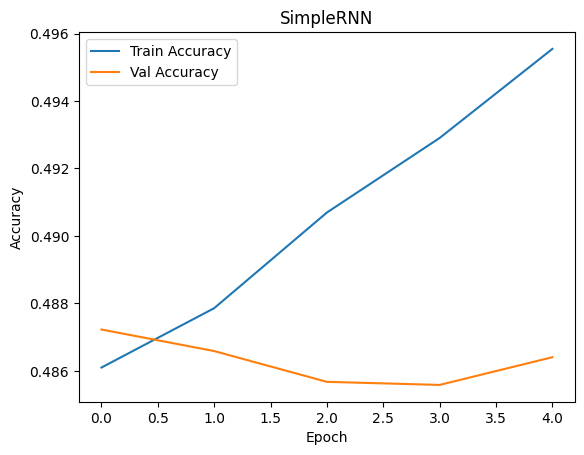

Epoch 1: Train Acc=0.5854, Val Acc=0.7004
Epoch 2: Train Acc=0.8237, Val Acc=0.8747
Epoch 3: Train Acc=0.9173, Val Acc=0.8926
Epoch 4: Train Acc=0.9515, Val Acc=0.8983
Epoch 5: Train Acc=0.9720, Val Acc=0.8954


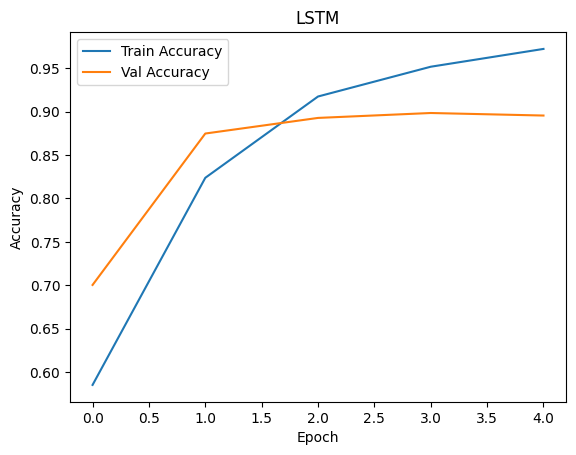

Epoch 1: Train Acc=0.7673, Val Acc=0.8650
Epoch 2: Train Acc=0.9082, Val Acc=0.8889
Epoch 3: Train Acc=0.9489, Val Acc=0.8958
Epoch 4: Train Acc=0.9712, Val Acc=0.8976
Epoch 5: Train Acc=0.9853, Val Acc=0.8940


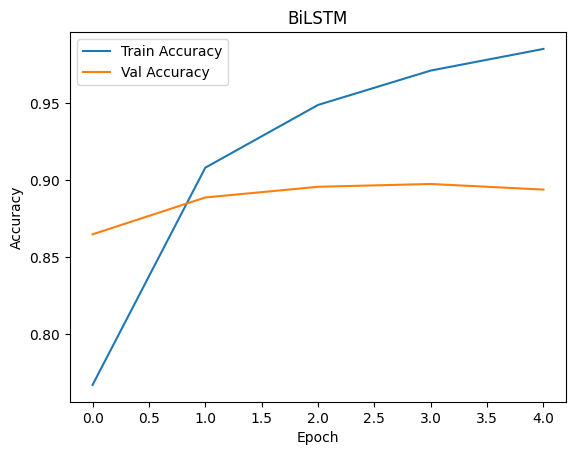

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rnn_model, rnn_train_accs, rnn_val_accs = run_experiment(SimpleRNN, "SimpleRNN")
lstm_model, lstm_train_accs, lstm_val_accs = run_experiment(LSTM, "LSTM")
bilstm_model, bilstm_train_accs, bilstm_val_accs = run_experiment(BiLSTM, "BiLSTM")

In [32]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

In [33]:
from transformers import BertTokenizer
texts = df["text"].tolist()
labels = df["category"].tolist()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

encodings = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=128
)

dataset = TextDataset(encodings, y)
bert_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,   
    pin_memory=True
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [34]:
from transformers import DistilBertModel

class DistilBERTClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")

        for param in self.bert.parameters():
            param.requires_grad = False

        hidden_size = self.bert.config.hidden_size
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden = outputs.last_hidden_state

        mask = attention_mask.unsqueeze(-1)
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

        return self.fc(pooled)

In [35]:
from tqdm import tqdm
import torch
import torch.nn as nn

def train_transformer(
    model,
    train_loader,
    val_loader,
    device,
    forward_fn,
    epochs=3,
    lr=2e-5
):

    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_accs = []
    val_accs = []

    print("🚀 Starting training...")

    for epoch in range(epochs):

        print(f"\n===== Epoch {epoch+1}/{epochs} =====")

        # ---------------- TRAIN ----------------
        model.train()
        correct, total, total_loss = 0, 0, 0

        loop = tqdm(train_loader, desc="Training")

        for batch in loop:

            optimizer.zero_grad()

            outputs = forward_fn(model, batch, device)
            labels = batch["labels"].to(device)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item())

        train_acc = correct / total
        train_accs.append(train_acc)

        print(f"📊 Train Acc: {train_acc:.4f}")

        # ---------------- VALIDATION ----------------
        if val_loader is not None:

            model.eval()
            correct, total = 0, 0

            with torch.no_grad():
                for batch in tqdm(val_loader, desc="Validation"):

                    outputs = forward_fn(model, batch, device)
                    labels = batch["labels"].to(device)

                    preds = outputs.argmax(dim=1)

                    correct += (preds == labels).sum().item()
                    total += labels.size(0)

            val_acc = correct / total
            val_accs.append(val_acc)

            print(f"📊 Val Acc: {val_acc:.4f}")

    print("\n✅ Training complete!")

    return model, train_accs, val_accs

In [36]:
def distil_forward(model, batch, device):
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)

    outputs = model(input_ids, attention_mask)

    if isinstance(outputs, tuple):
        outputs = outputs[0]

    return outputs

distil_model = DistilBERTClassifier(num_classes=len(set(y)))

encodings = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=128
)

dataset = TextDataset(encodings, y)

distil_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)
distil_model, train_accs, val_accs = train_transformer(
    distil_model,
    distil_loader,
    distil_loader,
    device,
    forward_fn=distil_forward
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🚀 Starting training...

===== Epoch 1/3 =====


...

📊 Val Acc: 0.8545

===== Epoch 3/3 =====


Training: 100%|██████████| 4568/4568 [04:51<00:00, 15.68it/s, loss=0.271]


📊 Train Acc: 0.8661


Validation: 100%|██████████| 4568/4568 [04:45<00:00, 15.99it/s]

📊 Val Acc: 0.8778

✅ Training complete!


## `Evaluation`

In [37]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_rnn_model(model, dataloader, device):

    model.eval()
    preds_list = []
    labels_list = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            preds = outputs.argmax(dim=1)

            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(y_batch.cpu().numpy())

    acc = accuracy_score(labels_list, preds_list)
    f1 = f1_score(labels_list, preds_list, average="weighted", zero_division=0)

    return acc, f1

In [38]:
def evaluate_transformer(model, dataloader, device):

    model.eval()
    preds_list = []
    labels_list = []

    with torch.no_grad():
        for batch in dataloader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            preds = torch.argmax(outputs, dim=1)

            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_list, preds_list)
    f1 = f1_score(labels_list, preds_list, average="weighted", zero_division=0)

    return acc, f1

In [ ]:
rnn_acc, rnn_f1 = evaluate_rnn_model(rnn_model, test_loader, device)
lstm_acc, lstm_f1 = evaluate_rnn_model(lstm_model, test_loader, device)
bilstm_acc, bilstm_f1 = evaluate_rnn_model(bilstm_model, test_loader, device)
distil_acc, distil_f1 = evaluate_transformer(distil_model, distil_loader, device)

In [42]:
# results = pd.DataFrame({
#     "Model": ["SimpleRNN", "LSTM", "BiLSTM", "DistilBERT"],
#     "Accuracy": [rnn_acc, lstm_acc, bilstm_acc,distil_acc],
#     "F1-score": [rnn_f1, lstm_f1, bilstm_f1, distil_f1]
# })

results = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM", "BiLSTM"],
    "Accuracy": [rnn_acc, lstm_acc, bilstm_acc],
    "F1-score": [rnn_f1, lstm_f1, bilstm_f1]
})

# Sort by F1-score (recommended)
results = results.sort_values(by="F1-score", ascending=False)

# Print clean table
print(results.to_string(index=False))

     Model  Accuracy  F1-score
      LSTM  0.900292  0.899551
    BiLSTM  0.898467  0.897926
DistilBERT  0.877833  0.873226
 SimpleRNN  0.484948  0.322937


In [99]:
from sklearn.metrics import confusion_matrix
import torch
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(
    model,
    dataloader,
    device,
    class_names,
    normalize=False,
    title="Confusion Matrix"
):
    model.eval()
    preds = []
    labels = []

    with torch.no_grad():
        for batch in dataloader:  # ✅ fixed indentation

            # 🔥 Case 1: BERT-style (dict)
            if isinstance(batch, dict):
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                y_batch = batch["labels"].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)

                # HuggingFace output
                if hasattr(outputs, "logits"):
                    outputs = outputs.logits

            # 🔥 Case 2: RNN/LSTM (tuple)
            else:
                X_batch, y_batch = batch
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)

                if isinstance(outputs, tuple):
                    outputs = outputs[0]

            pred = torch.argmax(outputs, dim=1)

            preds.extend(pred.detach().cpu().numpy())
            labels.extend(y_batch.detach().cpu().numpy())

    # Build confusion matrix
    cm = confusion_matrix(
        labels,
        preds,
        labels=list(range(len(class_names)))
    )

    # Normalize if needed
    if normalize:
        cm = cm.astype(float)
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm = cm / row_sums

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        square=True,
        cbar=True
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

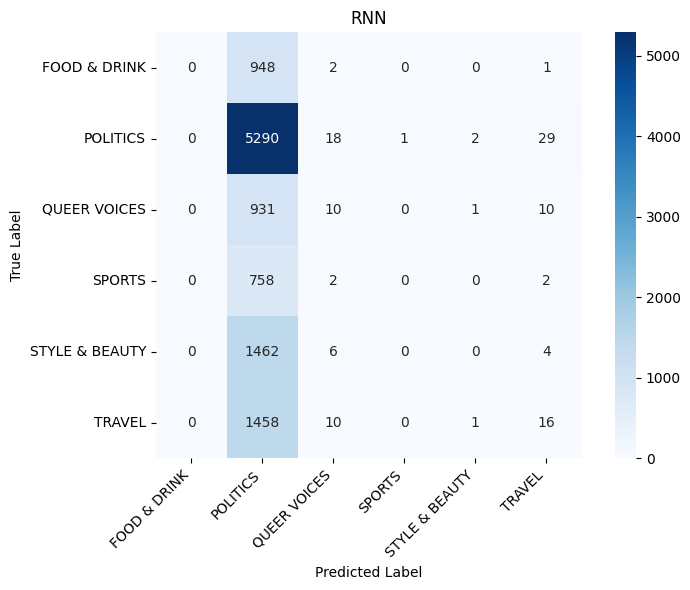

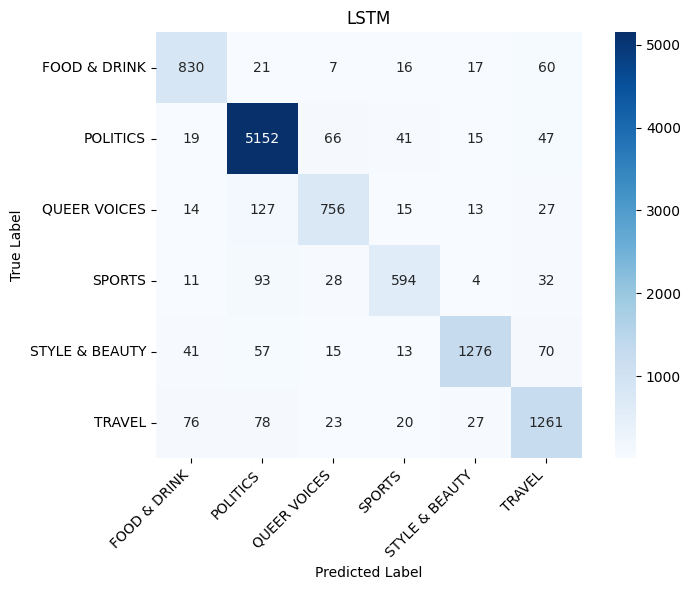

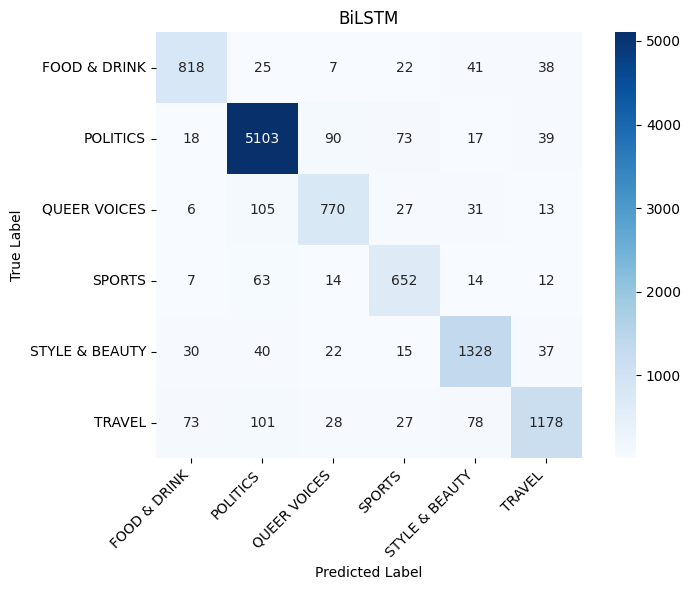

In [ ]:
class_names = list(le.classes_)
# RNN family
plot_confusion_matrix(rnn_model, test_loader, device, class_names, title="RNN")
plot_confusion_matrix(lstm_model, test_loader, device, class_names, title="LSTM")
plot_confusion_matrix(bilstm_model, test_loader, device, class_names, title="BiLSTM")
# Transformer
plot_confusion_matrix(distil_model, distil_loader, device, class_names, title="DistilBERT")

## `APPENDIX`

# FOCAL LOSS

In [ ]:
# import torch.nn.functional as F

# class FocalLoss(nn.Module):
#     def __init__(self, gamma=2.0, alpha=0.25):
#         super().__init__()
#         self.gamma = gamma
#         self.alpha = alpha

#     def forward(self, logits, targets):

#         ce_loss = F.cross_entropy(logits, targets, reduction="none")
#         pt = torch.exp(-ce_loss)

#         focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

#         return focal_loss.mean()

# TRAIN RNN - FOCAL LOSS

In [ ]:
# def train_model(model, train_loader, val_loader, device, epochs=5, lr=1e-3):
    
#     model.to(device)
#     optimizer = optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.FocalLoss(gamma=2.0, alpha=0.25)

#     train_accs, val_accs = [], []

#     for epoch in range(epochs):

#         model.train()
#         correct, total = 0, 0

#         for X_batch, y_batch in train_loader:
#             X_batch, y_batch = X_batch.to(device), y_batch.to(device)

#             optimizer.zero_grad()
#             outputs = model(X_batch)

#             loss = criterion(outputs, y_batch)
#             loss.backward()
#             optimizer.step()

#             preds = torch.argmax(outputs, dim=1)
#             correct += (preds == y_batch).sum().item()
#             total += y_batch.size(0)

#         train_acc = correct / total

#         # ---- validation ----
#         model.eval()
#         correct, total = 0, 0

#         with torch.no_grad():
#             for X_batch, y_batch in val_loader:
#                 X_batch, y_batch = X_batch.to(device), y_batch.to(device)

#                 outputs = model(X_batch)
#                 preds = torch.argmax(outputs, dim=1)

#                 correct += (preds == y_batch).sum().item()
#                 total += y_batch.size(0)

#         val_acc = correct / total

#         train_accs.append(train_acc)
#         val_accs.append(val_acc)

#         print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

#     return train_accs, val_accs

# TRAIN TRANSFORMER  - FOCAL LOSS

In [ ]:
# def train_transformer(model, train_loader, val_loader, device, epochs=3, lr=2e-5):

#     model.to(device)
#     optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
#     criterion = nn.FocalLoss(gamma=2.0, alpha=0.25)

#     for epoch in range(epochs):

#         model.train()
#         correct, total = 0, 0

#         for batch in train_loader:

#             input_ids = batch["input_ids"].to(device)
#             attention_mask = batch["attention_mask"].to(device)
#             labels = batch["labels"].to(device)

#             optimizer.zero_grad()

#             outputs = model(input_ids, attention_mask)

#             loss = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()

#             preds = outputs.argmax(dim=1)
#             correct += (preds == labels).sum().item()
#             total += labels.size(0)

#         print(f"Epoch {epoch+1} Train Acc: {correct/total:.4f}")

In [ ]:
# rnn_model = run_experiment(SimpleRNN, "SimpleRNN")
# lstm_model = run_experiment(LSTM, "LSTM")
# bilstm_model = run_experiment(BiLSTM, "BiLSTM")

In [ ]:
# distil_model = DistilBERTClassifier(num_classes=len(set(y)))

# train_transformer(
#     distil_model,
#     distil_loader,
#     distil_loader,
#     device
# )